# Step 1: Exploratory Data Analysis (EDA)
This notebook covers the initial exploration of the house price dataset to understand missing values, distributions, and correlations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

# Set plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)

Matplotlib is building the font cache; this may take a moment.


## 1. Load Data

In [3]:
DATA_PATH = "../data/raw/train.csv"
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Data loaded successfully. Shape: {df.shape}")
else:
    print("Error: data/raw/train.csv not found!")

df.head()

Data loaded successfully. Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Missing Values Analysis
Understanding what data is missing helps us decide on imputation strategies.

Top columns with missing values:
              Total    Percent
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageType       81   5.547945
GarageYrBlt      81   5.547945
GarageFinish     81   5.547945
GarageQual       81   5.547945
GarageCond       81   5.547945
BsmtFinType2     38   2.602740
BsmtExposure     38   2.602740
BsmtFinType1     37   2.534247
BsmtCond         37   2.534247
BsmtQual         37   2.534247
MasVnrArea        8   0.547945
Electrical        1   0.068493


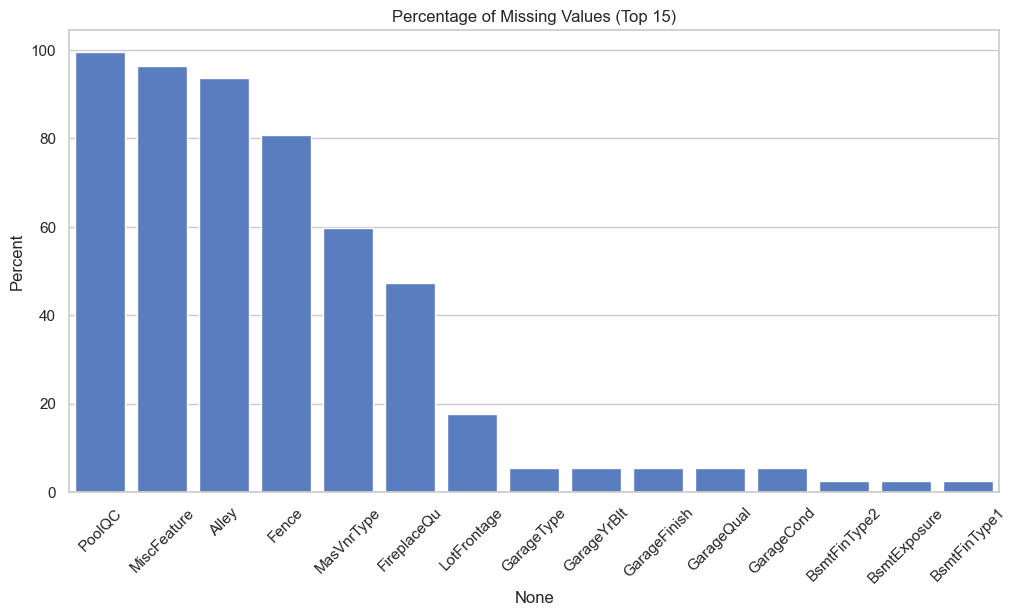

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.concat([missing, missing_percent], axis=1, keys=['Total', 'Percent'])
print("Top columns with missing values:")
print(missing_df.head(20))

# Visualize missing values
if not missing.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_df.index[:15], y=missing_df.Percent[:15])
    plt.xticks(rotation=45)
    plt.title("Percentage of Missing Values (Top 15)")
    plt.show()

## 3. Feature Distributions
Checking distributions helps identify skewness and potential outliers.

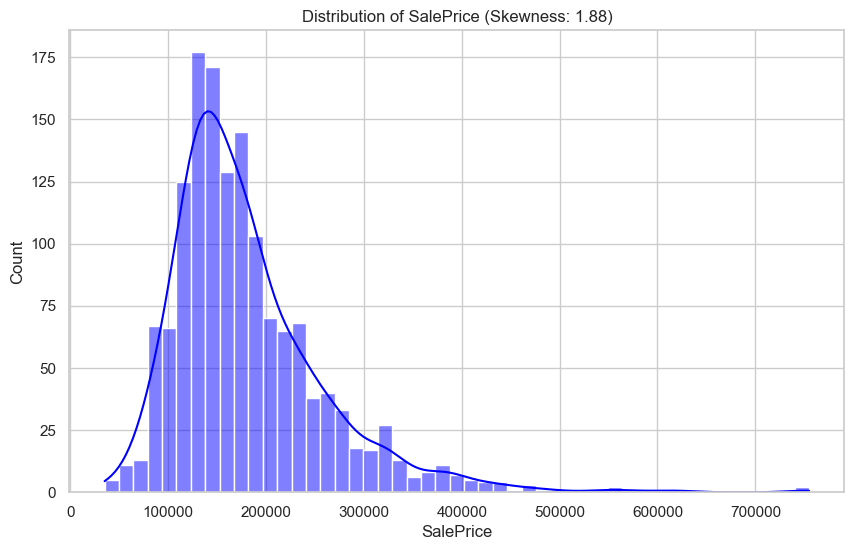

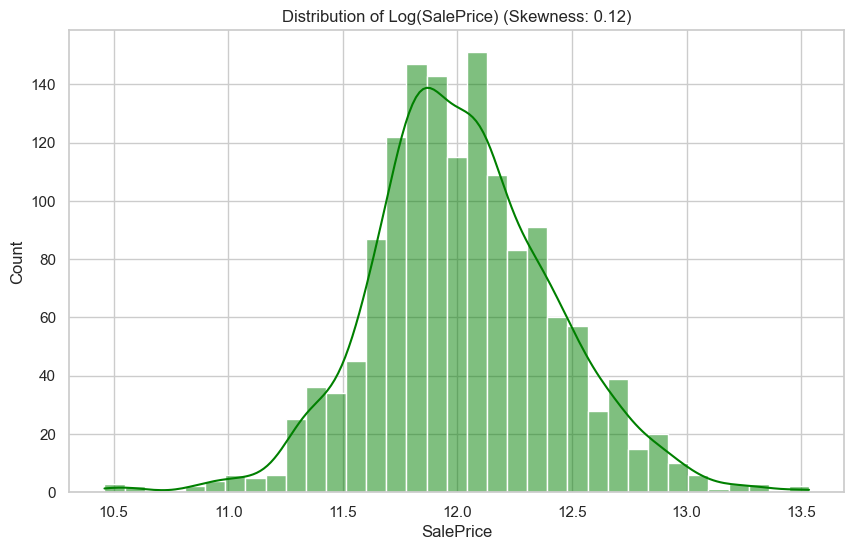

In [14]:
# Target Variable: SalePrice
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title(f"Distribution of SalePrice (Skewness: {df['SalePrice'].skew():.2f})")
plt.show()

# Log-transform SalePrice to normalize
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df['SalePrice']), kde=True, color='green')
plt.title(f"Distribution of Log(SalePrice) (Skewness: {np.log1p(df['SalePrice']).skew():.2f})")
plt.show()

In [ ]:
# Distribution of key numerical features
num_features = ['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt', 'GarageCars']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    sns.histplot(df[feat], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f"Distribution of {feat}")

plt.tight_layout()
plt.show()

## 4. Correlations
Identifying features that are most strongly correlated with the target `SalePrice`.

In [ ]:
# Select numerical columns for correlation
num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()

# Top 10 correlated features with SalePrice
top_correlations = corr_matrix['SalePrice'].sort_values(ascending=False).head(11)
print("Top 10 correlated features with SalePrice:")
print(top_correlations)

# Heatmap for top features
top_feat_list = top_correlations.index
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_feat_list].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlations with SalePrice (Top 10 Features)")
plt.show()